# Inverse Design: Learning the Wind from Trajectories

Because the AVBD solver is differentiable, we can optimize *through* it. Given a set of observed optimal trajectories, we back-propagate through the solver to recover the unknown current that produced them — a differentiable inverse-geometry problem.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. The inverse problem

We observe agents taking time-optimal routes across a sphere under an unknown current $W(x)$. Knowing
only their endpoints and chosen routes, can we infer $W$? Since `AVBDSolver.solve` is differentiable, we
define a loss on predicted-vs-observed paths and call `jax.value_and_grad`.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from ham.geometry import Randers, Sphere
from ham.solvers import AVBDSolver
from ham.vis import generate_icosphere
from ham.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_sphere,
                           plotly_path, plotly_cones)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
key = jax.random.PRNGKey(0)
sphere = Sphere(radius=1.0)

## 2. Ground-truth observations

The hidden current is a rotation about the $y$-axis, $W(x) = 0.8\,(\hat y \times x)$ — a global field,
non-zero everywhere except on the rotation axis. We generate six optimal trajectories with assorted
endpoints (not all on one great circle) so the observations probe the field broadly.

In [2]:
def true_wind(x):
    return 0.8 * jnp.cross(jnp.array([0.0, 1.0, 0.0]), x)


true_metric = Randers(sphere, lambda x: jnp.eye(3), true_wind)
solver = AVBDSolver(step_size=0.05, beta=5.0, iterations=100)


def unit(v):
    v = jnp.asarray(v, float)
    return v / jnp.linalg.norm(v)


pairs = [([1, 0, 0], [0, 0, -1]), ([0, 0, 1], [1, 0, 0]), ([-1, 0, 0], [0, 0, 1]),
         ([0, 0, -1], [-1, 0, 0]), ([1, 0, 0.3], [-1, 0, 0.3]), ([0.5, 0.5, 0.5], [-0.5, 0.5, -0.5])]
starts = [unit(s) for s, e in pairs]
ends = [unit(e) for s, e in pairs]
true_trajs = [solver.solve(true_metric, s, e, n_steps=20, key=key) for s, e in zip(starts, ends)]
print(f"generated {len(true_trajs)} observed trajectories")

generated 6 observed trajectories


## 3. Differentiable loss through the solver

We parameterize the current by a rotation vector $w$, rebuild the metric as $W(x)=w\times x$, re-solve
every trajectory, and measure the L2 gap to the observations. The gradient flows through the solver's
unrolled relaxation.

In [3]:
def make_metric(w):
    return Randers(sphere, lambda x: jnp.eye(3), lambda x: jnp.cross(w, x))


@jax.jit
def loss_fn(w):
    metric = make_metric(w)
    loss = 0.0
    for s, e, t in zip(starts, ends, true_trajs):
        pred = solver.solve(metric, s, e, n_steps=20, key=key)
        loss = loss + jnp.mean((pred.xs - t.xs) ** 2)
    return loss


loss_and_grad = jax.value_and_grad(loss_fn)

## 4. Optimize (Adam through AVBD)

In [4]:
w_param = jnp.zeros(3)
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(w_param)

history = []
for step in range(80):
    loss, grads = loss_and_grad(w_param)
    updates, opt_state = optimizer.update(grads, opt_state)
    w_param = optax.apply_updates(w_param, updates)
    history.append(float(loss))
    if step % 10 == 0:
        print(f"step {step:02d} | loss {loss:.2e} | w = {np.round(np.array(w_param), 3)}")

print(f"\ntrue rotation vector   : [0.   0.8  0. ]")
print(f"recovered rotation vec : {np.round(np.array(w_param), 3)}")

step 00 | loss 1.13e-02 | w = [-0.1  0.1  0.1]


step 10 | loss 3.18e-03 | w = [-0.001  0.754 -0.003]


step 20 | loss 4.40e-04 | w = [ 0.004  0.534 -0.011]


step 30 | loss 3.04e-04 | w = [0.016 0.616 0.012]


step 40 | loss 3.92e-05 | w = [-0.003  0.743 -0.004]


step 50 | loss 7.82e-05 | w = [0.002 0.774 0.001]


step 60 | loss 8.72e-06 | w = [ 0.     0.768 -0.002]


step 70 | loss 8.13e-06 | w = [0.001 0.769 0.001]



true rotation vector   : [0.   0.8  0. ]
recovered rotation vec : [0.    0.778 0.   ]


## 5. Convergence and recovery

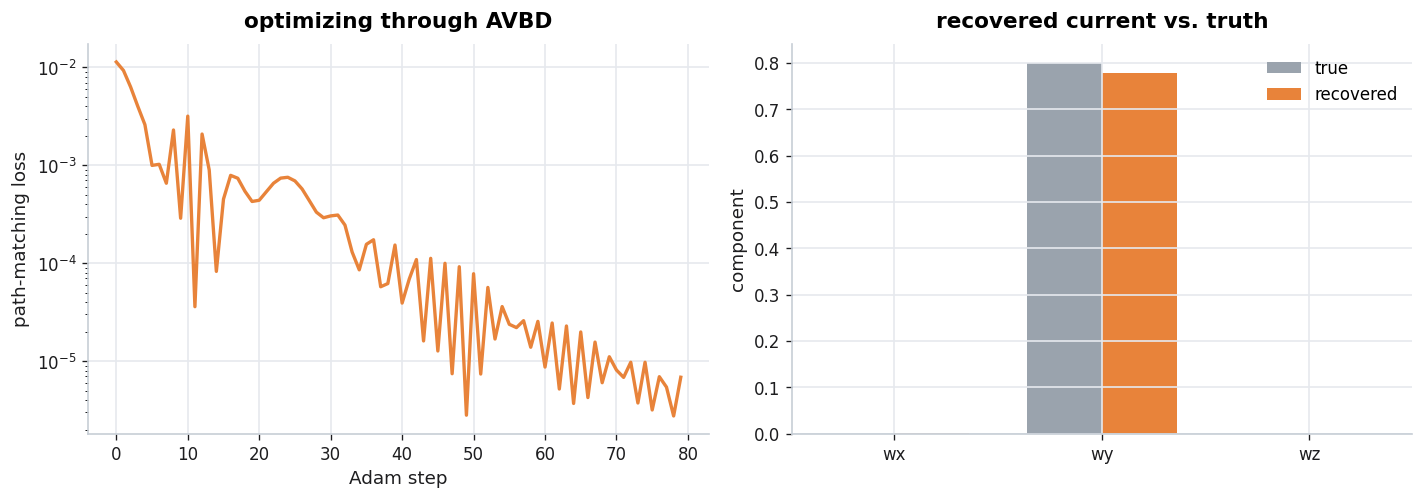

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].semilogy(history, color=PALETTE["accent"], lw=2)
ax[0].set(xlabel="Adam step", ylabel="path-matching loss", title="optimizing through AVBD")

labels = ["wx", "wy", "wz"]
xpos = np.arange(3)
ax[1].bar(xpos - 0.18, [0.0, 0.8, 0.0], width=0.36, label="true", color=PALETTE["muted"])
ax[1].bar(xpos + 0.18, np.array(w_param), width=0.36, label="recovered", color=PALETTE["accent"])
ax[1].set_xticks(xpos); ax[1].set_xticklabels(labels)
ax[1].set(title="recovered current vs. truth", ylabel="component"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. The recovered field and routes

The learned current is global; cone size follows the recovered wind speed (it spins about the $y$-axis
and fades on the axis). The recovered routes sit on top of the observations. Rotate the scene to check
the fit from any angle.

In [6]:
learned_metric = make_metric(w_param)
learned_trajs = [solver.solve(learned_metric, s, e, n_steps=20, key=key)
                 for s, e in zip(starts, ends)]

pts, _ = generate_icosphere(radius=1.0, subdivisions=3)
pts = np.array(pts)
Wl = np.array(jax.vmap(lambda p: sphere.to_tangent(p, jnp.cross(w_param, p)))(jnp.array(pts)))
keep = np.linalg.norm(Wl, axis=1) > 0.06

fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_cones(pts[keep], Wl[keep], name="learned wind", sizeref=0.3,
                           color=PALETTE["teal"]))
for i, (tt, tl) in enumerate(zip(true_trajs, learned_trajs)):
    fig.add_trace(plotly_path(tt.xs, color=PALETTE["muted"], width=7, dash="dash",
                              show_start=False, name="observed" if i == 0 else None))
    fig.add_trace(plotly_path(tl.xs, color=PALETTE["accent"], width=4,
                              show_start=False, name="recovered" if i == 0 else None))
plotly_layout(fig, "Recovered current and routes")
fig.show()

## 7. Notes

* `AVBDSolver.solve` is differentiable end-to-end, so `jax.value_and_grad` of a path-matching loss
  recovers the hidden current with no bespoke adjoint code.
* The field is global, so observations anywhere constrain it everywhere; the recovered routes match the
  observations across the sphere.
* The same recipe scales from this 3-parameter current to a neural `NeuralRanders` field — only the
  parameterization of `make_metric` changes.